# Forecasting — Transição Energética Brasileira

Este notebook aplica o Prophet para projetar as três curvas até 2030.

**Modelos:**
- Frota de veículos elétricos
- Capacidade solar instalada
- Vendas de combustíveis fósseis

**Horizonte:** 2026 até 2030

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)

# Carregar dataset integrado
df = pd.read_csv('../output/dataset_integrado.csv')
df['data'] = pd.to_datetime(df['data'])

print(f"Dados carregados: {df.shape}")
print(df.tail(5))

Importing plotly failed. Interactive plots will not work.


Dados carregados: (60, 4)
         data  frota_ev   solar_gw  combustivel_m3
55 2025-08-01    692847  42.294987    1.351759e+07
56 2025-09-01    722193  42.894372    1.381712e+07
57 2025-10-01    762172  43.568298    1.435653e+07
58 2025-11-01    795146  44.156544    1.296667e+07
59 2025-12-01    836151  44.811195    1.396128e+07


In [2]:
def treinar_prophet(df, coluna, changepoint_scale=0.05):
    df_prophet = df[['data', coluna]].rename(columns={'data': 'ds', coluna: 'y'})
    
    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=changepoint_scale
    )
    modelo.fit(df_prophet)
    
    futuro = modelo.make_future_dataframe(periods=60, freq='MS')
    forecast = modelo.predict(futuro)
    
    return forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# Treinar os três modelos
print("Treinando modelo de EVs...")
fc_ev = treinar_prophet(df, 'frota_ev', changepoint_scale=0.1)

print("Treinando modelo solar...")
fc_solar = treinar_prophet(df, 'solar_gw', changepoint_scale=0.05)

print("Treinando modelo combustíveis...")
fc_comb = treinar_prophet(df, 'combustivel_m3', changepoint_scale=0.05)

print("\nModelos treinados!")
print(f"Período previsto até: {fc_ev['ds'].max().strftime('%b/%Y')}")

19:48:56 - cmdstanpy - INFO - Chain [1] start processing


Treinando modelo de EVs...


19:48:57 - cmdstanpy - INFO - Chain [1] done processing
19:48:57 - cmdstanpy - INFO - Chain [1] start processing


Treinando modelo solar...


19:48:57 - cmdstanpy - INFO - Chain [1] done processing
19:48:58 - cmdstanpy - INFO - Chain [1] start processing


Treinando modelo combustíveis...


19:48:58 - cmdstanpy - INFO - Chain [1] done processing



Modelos treinados!
Período previsto até: Dec/2030


In [3]:
# Resultados para dezembro de 2030
ev_2030 = fc_ev[fc_ev['ds'] == '2030-12-01'].iloc[0]
solar_2030 = fc_solar[fc_solar['ds'] == '2030-12-01'].iloc[0]
comb_2030 = fc_comb[fc_comb['ds'] == '2030-12-01'].iloc[0]

# Valores atuais (Dez/2025)
ev_atual = df['frota_ev'].iloc[-1]
solar_atual = df['solar_gw'].iloc[-1]
comb_atual = df['combustivel_m3'].iloc[-1]

print("=" * 55)
print("PREVISÕES PARA DEZEMBRO DE 2030")
print("=" * 55)

print(f"\n🚗 FROTA ELÉTRICA:")
print(f"   Dez/2025 (atual):  {ev_atual:,.0f}")
print(f"   Dez/2030 (central): {ev_2030['yhat']:,.0f}")
print(f"   Dez/2030 (mínimo):  {ev_2030['yhat_lower']:,.0f}")
print(f"   Dez/2030 (máximo):  {ev_2030['yhat_upper']:,.0f}")
crescimento_ev = ((ev_2030['yhat'] / ev_atual) - 1) * 100
print(f"   Crescimento previsto: +{crescimento_ev:.0f}%")

print(f"\n☀️ CAPACIDADE SOLAR (GD):")
print(f"   Dez/2025 (atual):   {solar_atual:.1f} GW")
print(f"   Dez/2030 (central): {ev_2030['yhat']/1e6:.1f} GW")
print(f"   Dez/2030 (central): {solar_2030['yhat']:.1f} GW")
print(f"   Dez/2030 (mínimo):  {solar_2030['yhat_lower']:.1f} GW")
print(f"   Dez/2030 (máximo):  {solar_2030['yhat_upper']:.1f} GW")
crescimento_solar = ((solar_2030['yhat'] / solar_atual) - 1) * 100
print(f"   Crescimento previsto: +{crescimento_solar:.0f}%")

print(f"\n⛽ COMBUSTÍVEIS FÓSSEIS:")
print(f"   Dez/2025 (atual):   {comb_atual/1e6:.2f} M m³")
print(f"   Dez/2030 (central): {comb_2030['yhat']/1e6:.2f} M m³")
print(f"   Dez/2030 (mínimo):  {comb_2030['yhat_lower']/1e6:.2f} M m³")
print(f"   Dez/2030 (máximo):  {comb_2030['yhat_upper']/1e6:.2f} M m³")
variacao_comb = ((comb_2030['yhat'] / comb_atual) - 1) * 100
print(f"   Variação prevista: {variacao_comb:+.0f}%")

PREVISÕES PARA DEZEMBRO DE 2030

🚗 FROTA ELÉTRICA:
   Dez/2025 (atual):  836,151
   Dez/2030 (central): 2,447,834
   Dez/2030 (mínimo):  1,143,545
   Dez/2030 (máximo):  3,706,405
   Crescimento previsto: +193%

☀️ CAPACIDADE SOLAR (GD):
   Dez/2025 (atual):   44.8 GW
   Dez/2030 (central): 2.4 GW
   Dez/2030 (central): 89.1 GW
   Dez/2030 (mínimo):  55.7 GW
   Dez/2030 (máximo):  121.0 GW
   Crescimento previsto: +99%

⛽ COMBUSTÍVEIS FÓSSEIS:
   Dez/2025 (atual):   13.96 M m³
   Dez/2030 (central): 15.56 M m³
   Dez/2030 (mínimo):  15.15 M m³
   Dez/2030 (máximo):  16.00 M m³
   Variação prevista: +11%


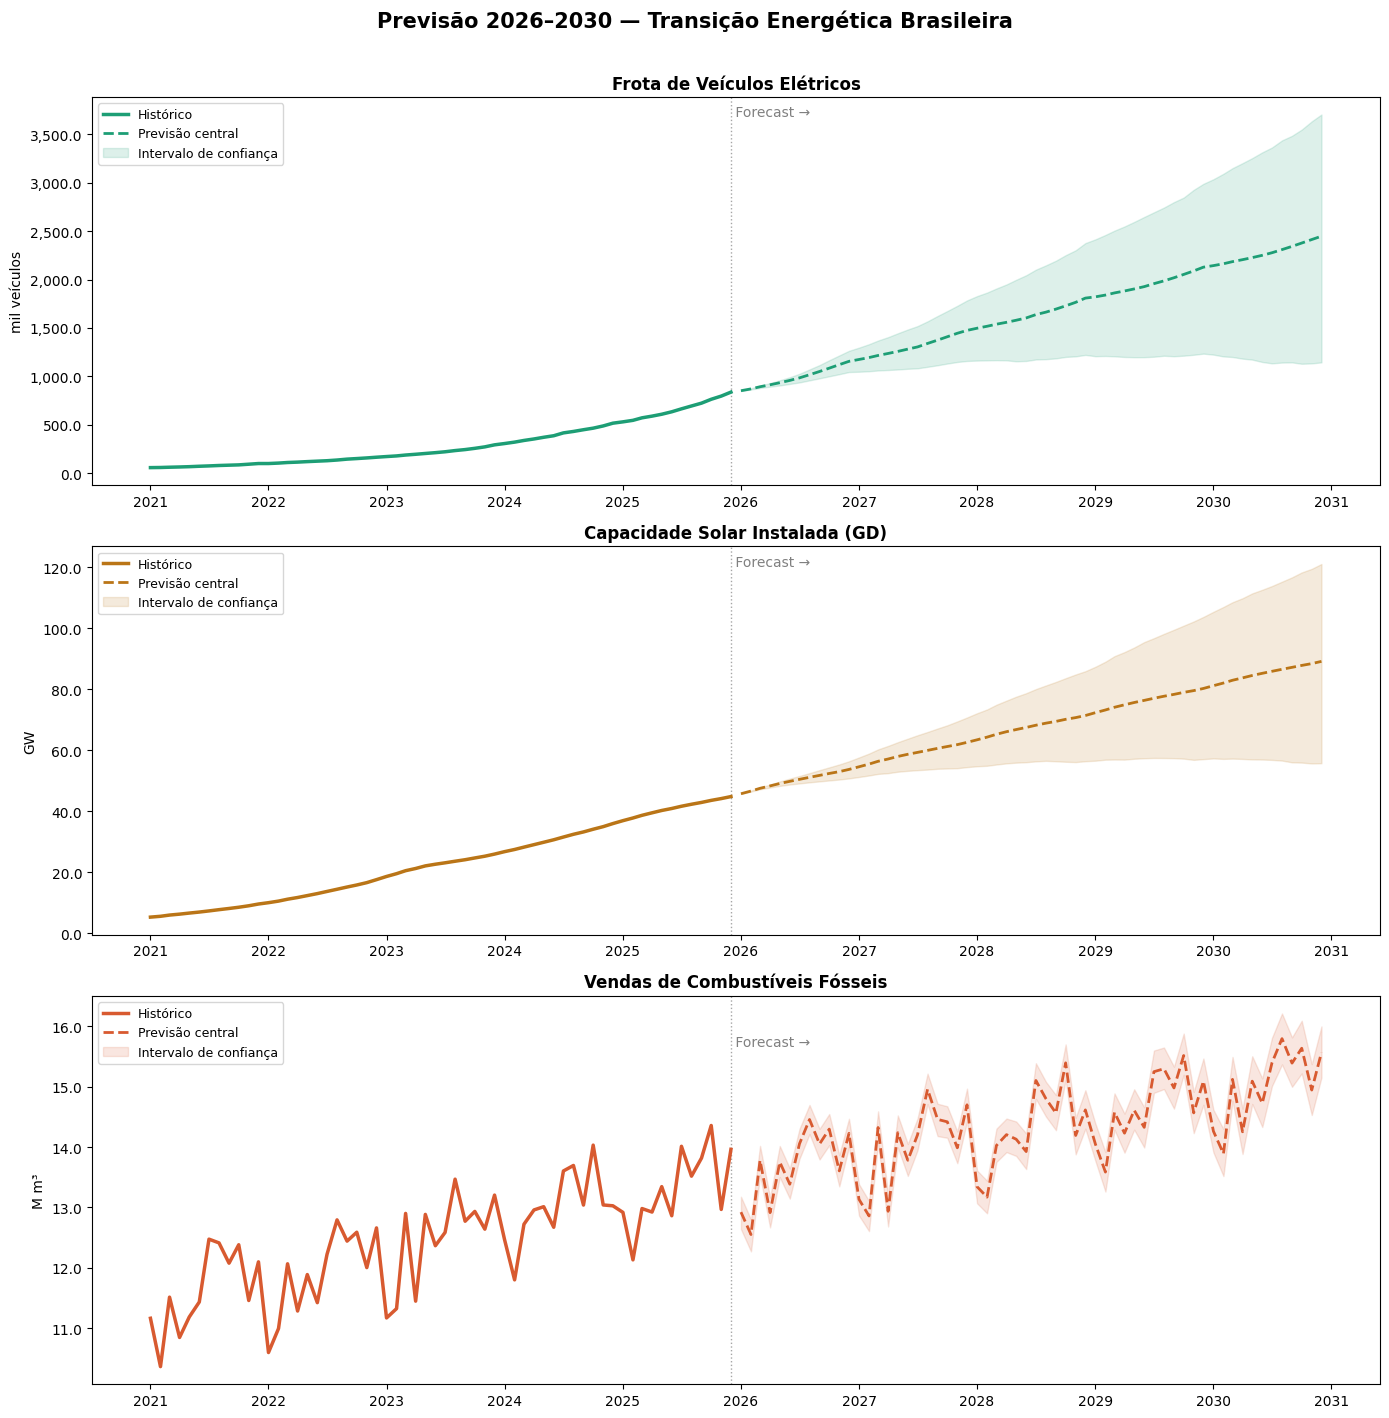

Gráfico salvo!


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Cores
cor_ev = '#1D9E75'
cor_solar = '#BA7517'
cor_comb = '#D85A30'

for ax, fc, df_col, cor, titulo, unidade, divisor in [
    (axes[0], fc_ev, 'frota_ev', cor_ev, 
     'Frota de Veículos Elétricos', 'mil veículos', 1000),
    (axes[1], fc_solar, 'solar_gw', cor_solar, 
     'Capacidade Solar Instalada (GD)', 'GW', 1),
    (axes[2], fc_comb, 'combustivel_m3', cor_comb, 
     'Vendas de Combustíveis Fósseis', 'M m³', 1e6)
]:
    # Dados históricos
    ax.plot(df['data'], df[df_col]/divisor, 
            color=cor, linewidth=2.5, label='Histórico', zorder=3)
    
    # Linha de forecast
    fc_futuro = fc[fc['ds'] > df['data'].max()]
    ax.plot(fc_futuro['ds'], fc_futuro['yhat']/divisor,
            color=cor, linewidth=2, linestyle='--', label='Previsão central')
    
    # Intervalo de confiança
    ax.fill_between(fc_futuro['ds'], 
                    fc_futuro['yhat_lower']/divisor,
                    fc_futuro['yhat_upper']/divisor,
                    alpha=0.15, color=cor, label='Intervalo de confiança')
    
    # Linha vertical separando histórico do forecast
    ax.axvline(x=df['data'].max(), color='gray', 
               linestyle=':', alpha=0.7, linewidth=1)
    ax.text(df['data'].max(), ax.get_ylim()[1]*0.95, 
            ' Forecast →', fontsize=10, color='gray')
    
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_ylabel(unidade)
    ax.legend(loc='upper left', fontsize=9)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x:,.1f}')
    )

plt.suptitle('Previsão 2026–2030 — Transição Energética Brasileira',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/forecast_transicao_energetica.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo!")

In [5]:
# Salvar os três forecasts
fc_ev.to_csv('../output/forecast_ev.csv', index=False)
fc_solar.to_csv('../output/forecast_solar.csv', index=False)
fc_comb.to_csv('../output/forecast_combustivel.csv', index=False)

# Resumo final do projeto
print("=" * 55)
print("PROJETO CONCLUÍDO — RESUMO FINAL")
print("=" * 55)

print(f"""
DADOS COLETADOS:
  SENATRAN: 60 arquivos Excel, 836k EVs rastreados
  ANEEL GD: 4,1 milhões de instalações solares
  ANP: Vendas de combustíveis 2015-2026

ACHADOS PRINCIPAIS:
  EVs cresceram +1.403% em 5 anos (55k → 836k)
  Solar cresceu +743% em 5 anos (5,3 → 44,8 GW)
  Combustíveis ainda crescem +25% (sem queda ainda)
  Solar cobre 4.695x a demanda energética dos EVs

PREVISÕES 2030:
  EVs: ~2,4 milhões (+193% vs 2025)
  Solar: ~89 GW (+99% vs 2025)
  Combustíveis: +11% — desaceleração clara

CONCLUSÃO ANALÍTICA:
  O Brasil não tem problema de energia para suportar EVs.
  O gargalo é preço dos veículos e rede de recarga.
  Ponto de inflexão dos combustíveis: provavelmente pós-2030.

ARQUIVOS GERADOS:
""")

import os
for f in sorted(os.listdir('../output')):
    kb = os.path.getsize(f'../output/{f}') / 1024
    print(f"  {f:<45} {kb:.1f} KB")

PROJETO CONCLUÍDO — RESUMO FINAL

DADOS COLETADOS:
  SENATRAN: 60 arquivos Excel, 836k EVs rastreados
  ANEEL GD: 4,1 milhões de instalações solares
  ANP: Vendas de combustíveis 2015-2026

ACHADOS PRINCIPAIS:
  EVs cresceram +1.403% em 5 anos (55k → 836k)
  Solar cresceu +743% em 5 anos (5,3 → 44,8 GW)
  Combustíveis ainda crescem +25% (sem queda ainda)
  Solar cobre 4.695x a demanda energética dos EVs

PREVISÕES 2030:
  EVs: ~2,4 milhões (+193% vs 2025)
  Solar: ~89 GW (+99% vs 2025)
  Combustíveis: +11% — desaceleração clara

CONCLUSÃO ANALÍTICA:
  O Brasil não tem problema de energia para suportar EVs.
  O gargalo é preço dos veículos e rede de recarga.
  Ponto de inflexão dos combustíveis: provavelmente pós-2030.

ARQUIVOS GERADOS:

  aneel_solar_serie_temporal.csv                8.1 KB
  anp_vendas_combustiveis.csv                   5.9 KB
  dataset_integrado.csv                         3.0 KB
  forecast_combustivel.csv                      8.1 KB
  forecast_ev.csv               